# Zadanie 4. Czy Karate Club jest grafem „nietypowym”?


Kacper Kaszuba

In [1]:
# import bibliotek
import networkx as nx
from networkx.algorithms.community import girvan_newman, louvain_communities, label_propagation_communities, asyn_fluidc
from networkx.algorithms.community.quality import modularity

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import pandas as pd
import numpy as np
import seaborn as sns

import random
from pprint import pprint



In [9]:
G = nx.karate_club_graph()
M = len(G.edges())
N = len(G.nodes())
p=(2*M) / (N * (N - 1))
print(f"Ilość węzłów (N) w grafie karate club wynosi: {N}\nIlość krawędzi (M): {M}\nPrawdopodobieństwo powstania krawędźi wynosi: {p}")

Ilość węzłów (N) w grafie karate club wynosi: 34
Ilość krawędzi (M): 78
Prawdopodobieństwo powstania krawędźi wynosi: 0.13903743315508021


In [12]:
clustering_coefficient = nx.average_clustering(G)
av_shortest_path = nx.average_shortest_path_length(G)
print(f"Prawdziwy średni clustering: {clustering_coefficient}\nPrawdziwą średnią długość ścieżki: {av_shortest_path}")

Prawdziwy średni clustering: 0.5706384782076823
Prawdziwą średnią długość ścieżki: 2.408199643493761


In [15]:
G_rand_list = []
for _ in range(0, 501):
  G_rand = nx.erdos_renyi_graph(N, p)
  if nx.is_connected(G_rand):
    cc_rand = nx.average_clustering(G_rand)
    asp_rand = nx.average_shortest_path_length(G_rand)
    G_rand_list.append({'cc': cc_rand, 'asp': asp_rand})

In [16]:
G_rand_list

[{'cc': 0.15252100840336136, 'asp': 2.698752228163993},
 {'cc': 0.11234827264239028, 'asp': 2.27807486631016},
 {'cc': 0.20666539343009932, 'asp': 2.2816399286987523},
 {'cc': 0.1446778711484594, 'asp': 2.515151515151515},
 {'cc': 0.11057422969187675, 'asp': 2.5597147950089125},
 {'cc': 0.12948179271708685, 'asp': 2.4224598930481283},
 {'cc': 0.10770308123249299, 'asp': 2.6666666666666665},
 {'cc': 0.11664332399626517, 'asp': 2.272727272727273},
 {'cc': 0.13762838468720823, 'asp': 2.4884135472370765},
 {'cc': 0.11706349206349206, 'asp': 2.374331550802139},
 {'cc': 0.12717086834733893, 'asp': 2.445632798573975},
 {'cc': 0.16239495798319328, 'asp': 2.2923351158645278},
 {'cc': 0.10324463118580765, 'asp': 2.3992869875222818},
 {'cc': 0.07698412698412699, 'asp': 2.4028520499108734},
 {'cc': 0.14983660130718954, 'asp': 2.4759358288770055},
 {'cc': 0.1500233426704015, 'asp': 2.536541889483066},
 {'cc': 0.14620575502928443, 'asp': 2.2976827094474155},
 {'cc': 0.15728715728715728, 'asp': 2.306

In [23]:
G_df = pd.DataFrame(G_rand_list)
G_df = G_df.rename(columns = {'cc':'AVG clustering', 'asp':'AVG shortest path length'})
G_df

,AVG clustering,AVG shortest path length
0,0.152521,2.698752
1,0.112348,2.278075
2,0.206665,2.281640
3,0.144678,2.515152
4,0.110574,2.559715
...,...,...
392,0.134570,2.377897
393,0.068908,2.631016
394,0.191036,2.201426
395,0.119631,2.741533


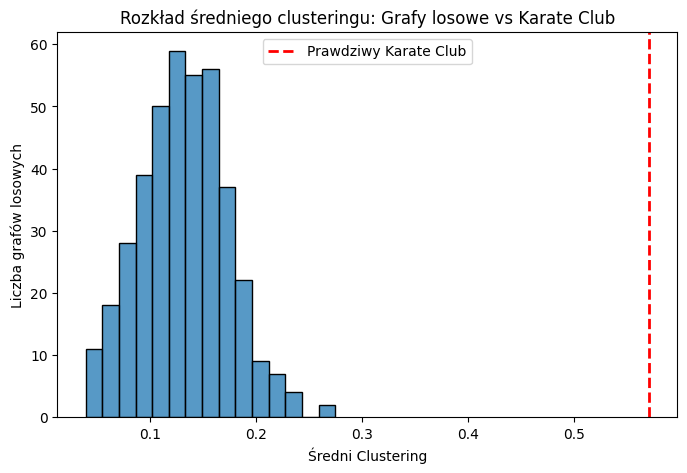

In [41]:
plt.figure(figsize=(8, 5))
sns.histplot(G_df['AVG clustering'], bins=15)
plt.axvline(x=clustering_coefficient, color="red", linestyle="--", linewidth=2, label="Prawdziwy Karate Club")
plt.title("Rozkład średniego clusteringu: Grafy losowe vs Karate Club")
plt.xlabel("Średni Clustering")
plt.ylabel("Liczba grafów losowych")
plt.legend()
plt.show()

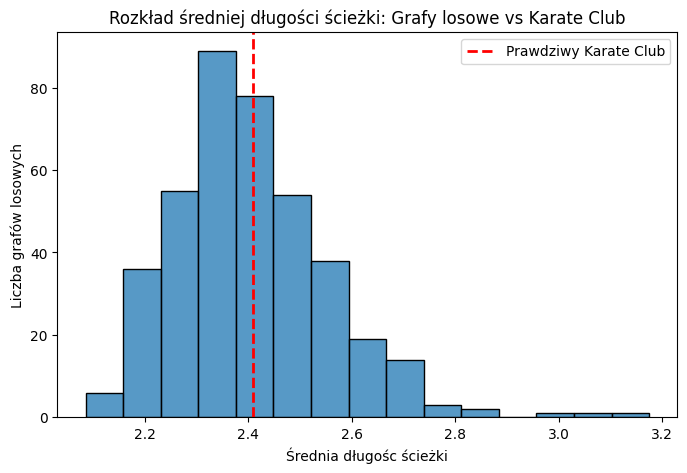

In [44]:
plt.figure(figsize=(8, 5))
sns.histplot(G_df['AVG shortest path length'], bins=15)
plt.axvline(x=av_shortest_path, color="red", linestyle="--", linewidth=2, label="Prawdziwy Karate Club")
plt.title("Rozkład średniej długości ścieżki: Grafy losowe vs Karate Club")
plt.xlabel("Średnia długośc ścieżki")
plt.ylabel("Liczba grafów losowych")
plt.legend()
plt.show()

# Notatki i wnioski do Zadania 4

### Parametry modelu losowego (Erdosa-Renyiego):
- **Liczba węzłów (N):** 34
- **Liczba krawędzi (M):** 78
- **Prawdopodobieństwo (p):** ~0.14 (wyliczone ze wzoru, aby grafy losowe miały średnio tyle samo krawędzi co sieć oryginalna).

### Wyniki eksperymentu dla Klubu Karate:
- Prawdziwy średni clustering: **0.57**
- Prawdziwa średnia długość ścieżki: **2.41**

### Interpretacja wyników (Własności strukturalnie szczególne):

1. **Średnia długość ścieżki (Miara Trywialna):**
- Wynik Klubu Karate (2.41) wylądował idealnie w środku rozkładu wyników z 500 grafów losowych.
- Oznacza to, że ta własność jest **trywialna**. "Krótkie dystanse" między ludźmi w tej sieci nie są niczym nadzwyczajnym i wynikają wprost z liczby węzłów i krawędzi, a nie ze specyficznej struktury społecznej. Ślepy los potrafi odtworzyć ten parametr.

2. **Średni clustering (Miara Nietrywialna):**
- Wyniki grafów losowych oscylowały wokół wartości 0.14. Tymczasem wynik Klubu Karate wystrzelił aż do **0.57** (poza wykres histogramu).
- Oznacza to, że clustering w badanej sieci jest własnością **nietrywialną (szczególną)**.
- **Wniosek społeczny:** Tego wyniku nie da się wytłumaczyć przypadkiem. Udowadnia to matematycznie, że w klubie karate ludzie dobierają się w małe, gęsto połączone paczki (trójkąty znajomości, zasada "znajomy mojego znajomego jest moim znajomym"), czego model losowy kompletnie nie potrafi odtworzyć.